# Ejercicio 1 — Análisis Exploratorio de Datos con Pandas

In [0]:
import pandas as pd

# Cargar dataset de AccuWeather que ya está en Databricks
df = spark.table("samples.accuweather.forecast_hourly_imperial").toPandas()

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 6850, Columnas: 39


,city_name,country_code,latitude,longitude,datetime_valid_local,gmt_offset,cloud_base_height,cloud_cover_perc_total,humidity_relative,index_uv,has_ice,ice_lwe,ice_probability,minutes_of_sun,has_precipitation,precipitation_lwe,precipitation_probability,precipitation_type_desc,has_rain,rain_lwe,rain_probability,snow_liquid_ratio_accuweather,has_snow,snow,snow_lwe,snow_probability,solar_irradiance,temperature,temperature_dew_point,temperature_heat_index,temperature_realfeel,temperature_realfeel_shade,temperature_wind_chill,thunderstorm_probability,visibility,weather_code,wind_direction,wind_gust,wind_speed
0,hong kong,hk,22.36851,114.17402,2024-07-15 05:00:00,8.0,1700,98.0,90.0,0.0,False,0.0,0,0,True,0.062,56,rain,True,0.062,56,0.0,False,0.0,0.0,0,0.0,81.26,78.10,89.83,88.95,88.95,81.26,16,5.0,12,87.0,17.0,7.0
1,hong kong,hk,22.36851,114.17402,2024-07-15 13:00:00,8.0,1700,98.0,68.0,2.0,False,0.0,0,1,True,0.023,58,rain,True,0.023,58,0.0,False,0.0,0.0,0,119.9,90.53,78.56,105.86,99.38,96.92,90.53,16,6.0,12,88.0,24.0,10.0
2,hong kong,hk,22.36851,114.17402,2024-07-15 14:00:00,8.0,1700,98.0,65.0,2.0,False,0.0,0,1,False,0.000,49,None,False,0.000,49,0.0,False,0.0,0.0,0,109.3,91.69,78.50,107.39,101.87,99.70,91.69,14,6.0,7,89.0,24.0,10.0
3,hong kong,hk,22.36851,114.17402,2024-07-15 06:00:00,8.0,1700,96.0,86.0,0.0,False,0.0,0,2,False,0.000,49,None,False,0.000,49,0.0,False,0.0,0.0,0,26.4,82.72,78.20,92.56,92.41,92.41,82.72,14,6.0,7,86.0,17.0,7.0
4,hong kong,hk,22.36851,114.17402,2024-07-15 07:00:00,8.0,1700,94.0,82.0,0.0,False,0.0,0,3,False,0.000,20,None,False,0.000,20,0.0,False,0.0,0.0,0,91.1,84.18,78.30,95.40,94.04,94.04,84.18,4,6.0,7,84.0,18.0,7.0


In [0]:
# Tipos de datos por columna
print("=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== INFO GENERAL ===")
df.info()

print("\n=== FORMA DEL DATASET ===")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

=== TIPOS DE DATOS ===
city_name                                object
country_code                             object
latitude                                float64
longitude                               float64
datetime_valid_local             datetime64[ns]
gmt_offset                              float64
cloud_base_height                         int32
cloud_cover_perc_total                  float64
humidity_relative                       float64
index_uv                                float64
has_ice                                    bool
ice_lwe                                 float64
ice_probability                           int32
minutes_of_sun                            int32
has_precipitation                          bool
precipitation_lwe                       float64
precipitation_probability                 int32
precipitation_type_desc                  object
has_rain                                   bool
rain_lwe                                float64
rain_probability 

In [0]:
# Columnas numéricas
cuantitativas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Variables cuantitativas:", cuantitativas)

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
df[cuantitativas].describe()

Variables cuantitativas: ['latitude', 'longitude', 'gmt_offset', 'cloud_cover_perc_total', 'humidity_relative', 'index_uv', 'ice_lwe', 'precipitation_lwe', 'rain_lwe', 'snow_liquid_ratio_accuweather', 'snow', 'snow_lwe', 'solar_irradiance', 'temperature', 'temperature_dew_point', 'temperature_heat_index', 'temperature_realfeel', 'temperature_realfeel_shade', 'temperature_wind_chill', 'visibility', 'wind_direction', 'wind_gust', 'wind_speed']

=== ESTADÍSTICAS DESCRIPTIVAS ===


,latitude,longitude,gmt_offset,cloud_cover_perc_total,humidity_relative,index_uv,ice_lwe,precipitation_lwe,rain_lwe,snow_liquid_ratio_accuweather,snow,snow_lwe,solar_irradiance,temperature,temperature_dew_point,temperature_heat_index,temperature_realfeel,temperature_realfeel_shade,temperature_wind_chill,visibility,wind_direction,wind_gust,wind_speed
count,6850.000000,6850.000000,6850.000000,6850.000000,6850.000000,6850.000000,6850.0,6850.000000,6850.000000,6850.0,6850.0,6850.0,6850.000000,6850.000000,6850.000000,6850.000000,6850.000000,6850.000000,6850.000000,6850.000000,6850.000000,6850.000000,6850.000000
mean,23.347118,30.376117,2.300000,57.197664,66.723942,1.816496,0.0,0.007649,0.007649,0.0,0.0,0.0,218.641927,77.081509,62.765486,80.075463,80.384731,78.586822,77.024801,7.506594,181.606277,12.663358,6.835182
std,24.525416,76.286818,4.984338,40.297956,22.171852,2.778280,0.0,0.042449,0.042449,0.0,0.0,0.0,317.515463,13.946220,13.129039,17.083518,17.084945,16.477186,14.083860,3.065777,95.765591,5.982303,3.385033
min,-34.607570,-157.845360,-10.000000,0.000000,6.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,30.770000,27.800000,27.860000,32.060000,31.800000,27.470000,0.250000,0.000000,0.000000,0.000000
25%,14.589920,-17.451910,0.000000,12.000000,55.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,68.000000,53.070000,67.617500,67.992500,65.602500,68.000000,5.000000,110.000000,8.000000,5.000000
50%,26.845870,33.240180,2.500000,70.000000,72.000000,1.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,32.400000,80.030000,65.800000,81.720000,84.120000,82.085000,80.030000,10.000000,186.000000,12.000000,6.000000
75%,39.917300,100.521010,7.000000,99.000000,84.000000,3.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,387.075000,86.000000,74.500000,92.720000,93.447500,91.630000,86.000000,10.000000,254.000000,16.000000,8.000000
max,64.137380,151.208850,10.000000,100.000000,100.000000,14.000000,0.0,1.514000,1.514000,0.0,0.0,0.0,1091.300000,123.670000,82.940000,122.410000,124.490000,120.330000,123.670000,21.740000,360.000000,49.000000,28.000000


In [0]:
print("=== MEDIA ===")
print(df[cuantitativas].mean())

print("\n=== MEDIANA ===")
print(df[cuantitativas].median())

print("\n=== DESVIACIÓN ESTÁNDAR ===")
print(df[cuantitativas].std())

print("\n=== VALORES NULOS ===")
print(df[cuantitativas].isnull().sum())

=== MEDIA ===
latitude                          23.347118
longitude                         30.376117
gmt_offset                         2.300000
cloud_cover_perc_total            57.197664
humidity_relative                 66.723942
index_uv                           1.816496
ice_lwe                            0.000000
precipitation_lwe                  0.007649
rain_lwe                           0.007649
snow_liquid_ratio_accuweather      0.000000
snow                               0.000000
snow_lwe                           0.000000
solar_irradiance                 218.641927
temperature                       77.081509
temperature_dew_point             62.765486
temperature_heat_index            80.075463
temperature_realfeel              80.384731
temperature_realfeel_shade        78.586822
temperature_wind_chill            77.024801
visibility                         7.506594
wind_direction                   181.606277
wind_gust                         12.663358
wind_speed        

In [0]:
# Columnas categóricas/texto
cualitativas = df.select_dtypes(include=['object']).columns.tolist()
print("Variables cualitativas:", cualitativas)

print("\n=== FRECUENCIAS ===")
for col in cualitativas:
    print(f"\n-- {col} --")
    print(df[col].value_counts())

Variables cualitativas: ['city_name', 'country_code', 'precipitation_type_desc']

=== FRECUENCIAS ===

-- city_name --
city_name
hong kong       137
tehran          137
new york        137
bogota          137
tokyo           137
cape town       137
dhaka           137
istanbul        137
shanghai        137
taipei city     137
buenos aires    137
honolulu        137
bangkok         137
osaka-shi       137
kolkata         137
singapore       137
lima            137
santiago        137
jakarta         137
kabul           137
são paulo       137
reykjavik       137
sydney          137
los angeles     137
paris           137
manila          137
beijing         137
baghdad         137
mumbai          137
amsterdam       137
toronto         137
delhi           137
havana          137
berlin          137
london          137
bengaluru       137
jerusalem       137
dakar           137
cairo           137
hanoi           137
stockholm       137
belgrade        137
athens          137
karachi    

## ¿Cómo se relaciona este análisis con DLM, DL y CRISP-DM?

El EDA encaja en la fase de Data Understanding de CRISP-DM, que es donde 
se explora el dataset antes de hacer cualquier otra cosa. Sin entender qué tipos 
de datos tienes, cuántos nulos hay o cómo se distribuyen las variables, no tiene 
sentido avanzar a modelar o transformar datos.

En DLM y DL pasa lo mismo: siempre hay una etapa inicial de exploración y 
comprensión antes de construir pipelines o modelos. El EDA es básicamente esa 
etapa, te da el contexto necesario para tomar decisiones sobre los datos.

#Ejercicio 2 — Crear gráficos usando paquetes de Python (matplotlib, seaborn, etc)

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

print("librerias importadas correctamente")

librerias importadas correctamente


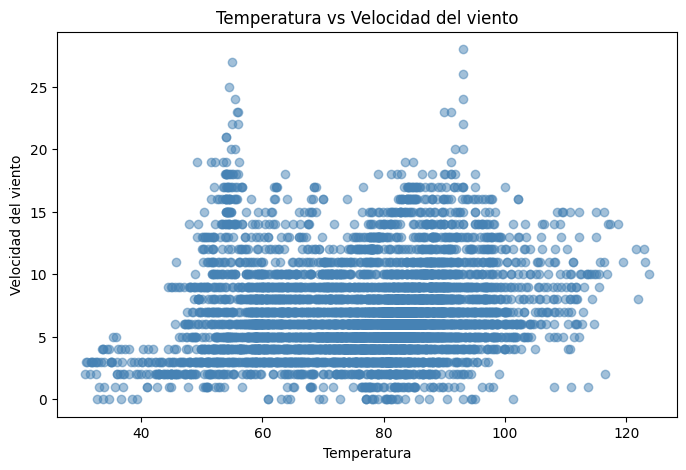

In [0]:
plt.figure(figsize=(8,5))
plt.scatter(df['temperature'], df['wind_speed'], alpha=0.5, color='steelblue')
plt.title('Temperatura vs Velocidad del viento')
plt.xlabel('Temperatura')
plt.ylabel('Velocidad del viento')
plt.show()

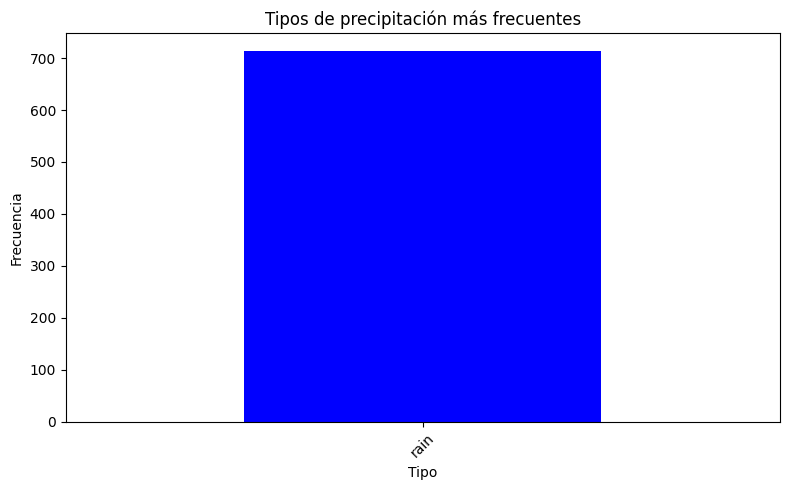

In [0]:
plt.figure(figsize=(8,5))
df['precipitation_type_desc'].value_counts().head(10).plot(kind='bar', color='blue')
plt.title('Tipos de precipitación más frecuentes')
plt.xlabel('Tipo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

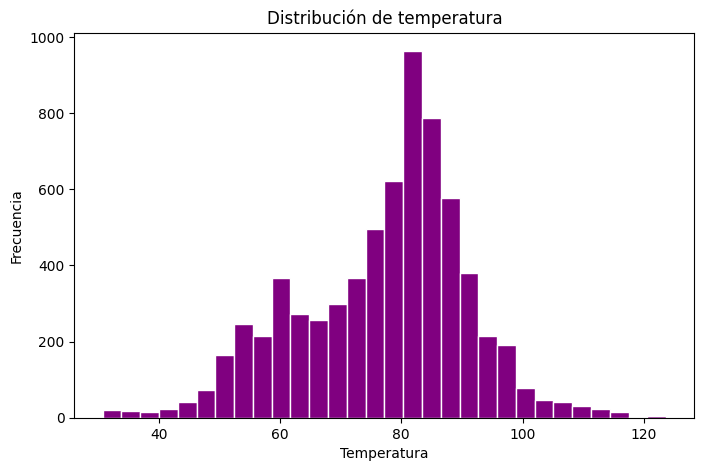

In [0]:
plt.figure(figsize=(8,5))
plt.hist(df['temperature'].dropna(), bins=30, color='purple', edgecolor='white')
plt.title('Distribución de temperatura')
plt.xlabel('Temperatura')
plt.ylabel('Frecuencia')
plt.show()

## ¿Cómo se podría identificar el tipo de gráfico ideal para presentar información de un dataset?

Pues primero debemos de ver que tipo de informacion tenemos. A partir de ver nuestros datos podemos definir que graficos haran que nuestros datos o informacion se vea mas ordenada y se puedan entender mejor. Por ejemplo aqui el scatter plot no sirve mucho ya que la dataset no se presta a hacer ese grafico pero por ejemplo el histograma si se ve bien y si presenta bien la informacion del dataset. Asi que todo depende de la info de tu dataset. 

# Ejercicio 3 — Análisis numérico complementado con gráficos

=== Temperatura ===
count    6850.000000
mean       77.081509
std        13.946220
min        30.770000
25%        68.000000
50%        80.030000
75%        86.000000
max       123.670000
Name: temperature, dtype: float64


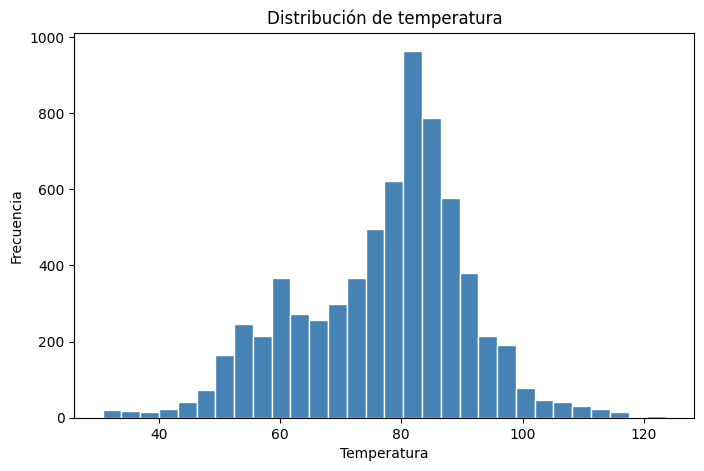

In [0]:
# Estadísticas
print("=== Temperatura ===")
print(df['temperature'].describe())

# Histograma
plt.figure(figsize=(8,5))
plt.hist(df['temperature'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución de temperatura')
plt.xlabel('Temperatura')
plt.ylabel('Frecuencia')
plt.show()

Correlación temperatura vs humedad: -0.5137114102376688


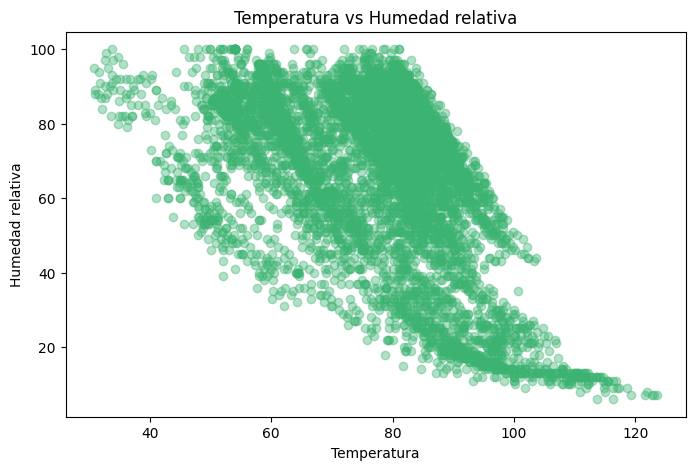

In [0]:
# Correlación
print("Correlación temperatura vs humedad:", df['temperature'].corr(df['humidity_relative']))

# Scatter
plt.figure(figsize=(8,5))
plt.scatter(df['temperature'], df['humidity_relative'], alpha=0.4, color='mediumseagreen')
plt.title('Temperatura vs Humedad relativa')
plt.xlabel('Temperatura')
plt.ylabel('Humedad relativa')
plt.show()

=== Tipos de precipitación ===
precipitation_type_desc
rain    713
Name: count, dtype: int64


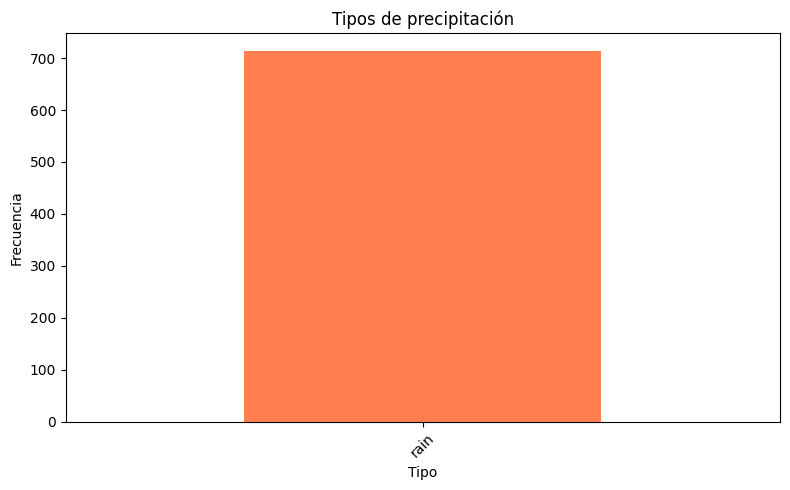

In [0]:
# Frecuencias
print("=== Tipos de precipitación ===")
print(df['precipitation_type_desc'].value_counts())

# Bar plot
plt.figure(figsize=(8,5))
df['precipitation_type_desc'].value_counts().plot(kind='bar', color='coral')
plt.title('Tipos de precipitación')
plt.xlabel('Tipo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

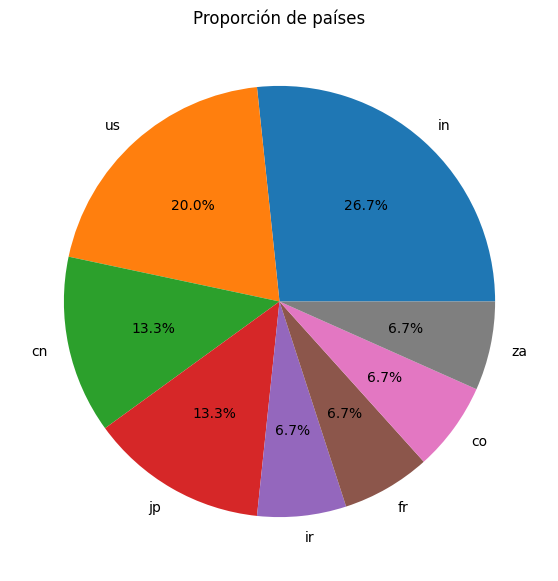

In [0]:
plt.figure(figsize=(7,7))
df['country_code'].value_counts().head(8).plot(kind='pie', autopct='%1.1f%%')
plt.title('Proporción de países')
plt.ylabel('')
plt.show()

## ¿Tendría sentido incluir un Análisis Exploratorio de Datos en un pipeline de datos?

Sí, tiene mucho sentido. Antes de transformar o cargar datos en un pipeline,
es útil hacer un EDA automatizado que detecte problemas como valores nulos,
outliers o columnas con tipos incorrectos. Esto evita que datos sucios lleguen
a las siguientes etapas y arruinen el análisis o el modelo.

# Ejercicio 4 — Manejo de metadata

In [0]:
%sh
echo "=== Python version ==="
python3 --version

echo "=== Pandas instalado ==="
pip show pandas

echo "=== Matplotlib instalado ==="
pip show matplotlib

=== Python version ===
Python 3.12.3
=== Pandas instalado ===
Name: pandas
Version: 2.2.3
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License
        
        Copyright (c) 2008-2011, AQR Capital Management, LLC, Lambda Foundry, Inc. and PyData Development Team
        All rights reserved.
        
        Copyright (c) 2011-2023, Open source contributors.
        
        Redistribution and use in source and binary forms, with or without
        modification, are permitted provided that the following conditions are met:
        
        * Redistributions of source code must retain the above copyright notice, this
          list of conditions and the following disclaimer.
        
        * Redistributions in binary form must reproduce the above copyright notice,
          this list of conditions and the following dis

In [0]:
print("=== Metadata del DataFrame ===")
print(f"Filas:       {df.shape[0]}")
print(f"Columnas:    {df.shape[1]}")
print(f"Memoria:     {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

print("\n=== Tipos de datos ===")
print(df.dtypes)

print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())

=== Metadata del DataFrame ===
Filas:       6850
Columnas:    39
Memoria:     2425.45 KB

=== Tipos de datos ===
city_name                                object
country_code                             object
latitude                                float64
longitude                               float64
datetime_valid_local             datetime64[ns]
gmt_offset                              float64
cloud_base_height                         int32
cloud_cover_perc_total                  float64
humidity_relative                       float64
index_uv                                float64
has_ice                                    bool
ice_lwe                                 float64
ice_probability                           int32
minutes_of_sun                            int32
has_precipitation                          bool
precipitation_lwe                       float64
precipitation_probability                 int32
precipitation_type_desc                  object
has_rain               

In [0]:
import importlib.metadata

paquetes = ['pandas', 'matplotlib', 'seaborn', 'numpy']

for p in paquetes:
    meta = importlib.metadata.metadata(p)
    print(f"{meta['Name']} — v{meta['Version']} — {meta['Summary']}")

pandas — v2.2.3 — Powerful data structures for data analysis, time series, and statistics
matplotlib — v3.10.0 — Python plotting package
seaborn — v0.13.2 — Statistical data visualization
numpy — v2.1.3 — Fundamental package for array computing in Python


## ¿Cómo beneficiaría un buen manejo de metadata a un pipeline de datos?

Con metadata bien manejada puedes validar automáticamente que los datos cumplen
lo esperado antes de cada etapa, lo que hace el pipeline más robusto y fácil
de debuggear cuando algo sale mal.

# Ejercicio 5 — Creación de página para Portafolio


## LINK DE GITHUB PAGE:
https://danielpinol.github.io/Lab2_EDA_Intro_a_Datos/

#¿Cuál sería el archivo ideal para mostrar los proyectos en una página de Portafolio?
El archivo ideal es index.html. Este es el archivo que los navegadores abren
automáticamente cuando alguien entra a tu página, sin necesidad de escribir
el nombre del archivo en la URL.